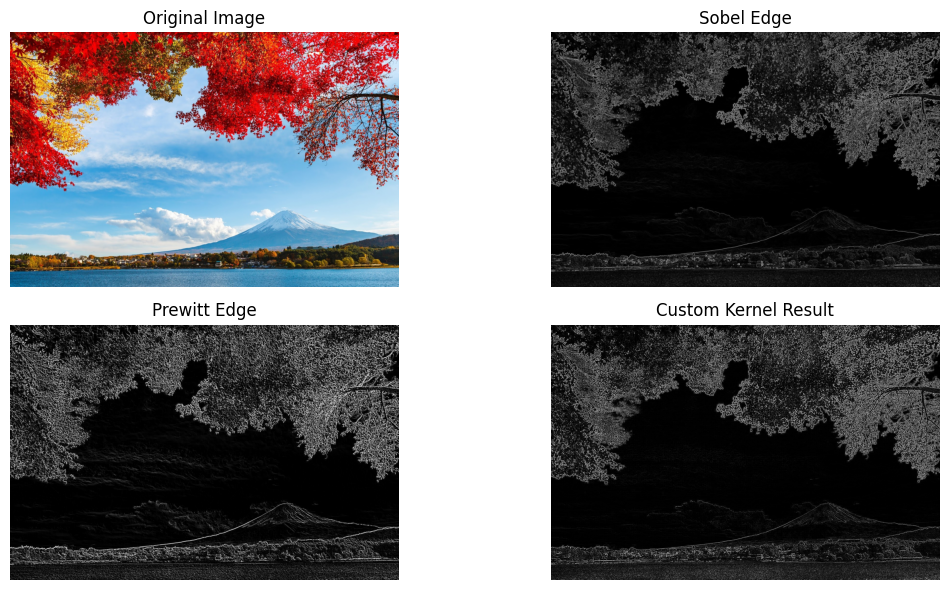

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh và chuyển sang ảnh xám (grayscale)
img = cv2.imread('../input/lab_image.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. Phát hiện cạnh bằng Sobel
# Tính gradient theo hướng X (cạnh dọc) và Y (cạnh ngang)
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Kết hợp hai hướng bằng biên độ gradient
sobel = cv2.magnitude(sobel_x, sobel_y)

# 2. Phát hiện cạnh bằng Prewitt
# Dùng kernel Prewitt thủ công với cv2.filter2D
kernelx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

kernely = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
])

prewitt_x = cv2.filter2D(gray, -1, kernelx)
prewitt_y = cv2.filter2D(gray, -1, kernely)

prewitt = prewitt_x + prewitt_y

# 3. Kernel tự thiết kế (Laplacian-like)
# Phát hiện cạnh theo tất cả 8 hướng xung quanh pixel trung tâm
custom_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

custom_result = cv2.filter2D(gray, -1, custom_kernel)

# Hiển thị kết quả bằng matplotlib (thay thế cv2.imshow cho Jupyter)
edge_images = [
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB),  # Ảnh gốc
    sobel,
    prewitt,
    custom_result
]
edge_titles = ["Original Image", "Sobel Edge", "Prewitt Edge", "Custom Kernel Result"]

plt.figure(figsize=(12, 6))
for i, (img_show, title) in enumerate(zip(edge_images, edge_titles)):
    plt.subplot(2, 2, i + 1)
    if i == 0:  # Ảnh gốc màu
        plt.imshow(img_show)
    else:       # Các ảnh cạnh là grayscale
        plt.imshow(img_show, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()